# Import de bibliotecas


In [ ]:
!pip install kneed

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler, RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from kneed import KneeLocator
from yellowbrick.cluster import SilhouetteVisualizer
from itertools import combinations
import plotly.express as px
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
from sklearn.neighbors import KNeighborsClassifier
from kneed import knee_locator


#Load do DF

In [ ]:
import pandas as pd

# Carrega o dataset
df = pd.read_csv("dataset_processed.csv", encoding='utf-8', low_memory=True)

# Tratamento de valores faltantes

In [ ]:
# prompt: Eu quero a quantidade de valores unicos nas colunas track_name e artits do df

print(df['track_name'].nunique())
print(df['artists'].nunique())

KeyError: 'track_name'

In [ ]:
# 1. Mostrar quantidade total de valores nulos por coluna
print('Valores nulos por coluna:')
linhas_com_nulos = df[df.isnull().any(axis=1)]
print(linhas_com_nulos)



Valores nulos por coluna:
Empty DataFrame
Columns: [duration_ms, explicit, danceability, energy, loudness, speechiness, acousticness, instrumentalness, liveness, valence, tempo, key_1, key_2, key_3, key_4, key_5, key_6, key_7, key_8, key_9, key_10, key_11, mode_1, time_signature_1, time_signature_3, time_signature_4, time_signature_5, is_popular]
Index: []

[0 rows x 28 columns]


In [ ]:
# Remove coluna de índice automática, se existir
df = df.drop(columns=['Unnamed: 0'], errors='ignore')

# Mantém apenas a primeira linha de cada track_id (uma linha por música)
df_amostrado = df.drop_duplicates(subset=['track_name', 'artists'], keep='first')


print(df_amostrado)



KeyError: Index(['track_name', 'artists'], dtype='object')

# Transformação de dados

In [ ]:
# Copiar o DataFrame original
df_transf = df.copy()
display(df_transf.head())

# Remover a coluna original de popularidade (já representada por is_popular), se existir
if 'popularity' in df_transf.columns:
    df_transf = df_transf.drop(columns=['popularity'])

# X e y já estão definidos em EtPLSdgWmmUi usando df_transf

,duration_ms,explicit,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,...,key_8,key_9,key_10,key_11,mode_1,time_signature_1,time_signature_3,time_signature_4,time_signature_5,is_popular
0,-0.006401,-0.305842,0.656701,-0.672851,0.348357,0.463078,-0.875018,-0.557105,0.697427,0.955723,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1
1,-0.702198,-0.305842,-0.783568,-1.813442,-1.628934,-0.108828,1.748240,-0.557091,-0.598786,-0.745232,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0
2,-0.176710,-0.305842,-0.682299,-1.067225,-0.214914,-0.285459,-0.352014,-0.557108,-0.518088,-1.303357,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0
3,-0.253049,-0.305842,-1.649981,-2.224829,-1.870228,-0.451801,1.692351,-0.556895,-0.442433,-1.216032,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1
4,-0.279488,-0.305842,0.330390,-0.742446,-0.204923,-0.312039,0.409843,-0.557108,-0.690075,-1.124909,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1


# Aplicação SVM - Mateus

In [ ]:
# 1. Divide em conjuntos de treino e teste

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler # Import StandardScaler


# Use the df_transf DataFrame that already has the transformations
# Separar features (X) e target (y)
X = df_transf.drop(columns=['is_popular'])
y = df_transf['is_popular']

# Agora dividimos os dados
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# Aplica SMOTE para balancear as classes no conjunto de treino reduzido para SVM
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_svm, y_train_svm) # Use X_train_svm and y_train_svm here

print("\nDistribuição das classes após SMOTE (amostra reduzida para SVM):")
print(pd.Series(y_train_bal).value_counts())

# Keep X_test and y_test as they are for final evaluation on the full test set
print("\nTamanho do conjunto de teste para avaliação final:")
print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")


Distribuição das classes após SMOTE (amostra reduzida para SVM):
is_popular
0    5076
1    5076
Name: count, dtype: int64

Tamanho do conjunto de teste para avaliação final:
X_test: (24404, 27)
y_test: (24404,)


In [ ]:
# 2. Cria e treina o modelo SVM
svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    random_state=42,
    probability=True
)

svm_model.fit(X_train_bal, y_train_bal)

SVC(probability=True, random_state=42)

Matriz de Confusão (Teste - SVM):
[[15035  6719]
 [ 1221  1429]]


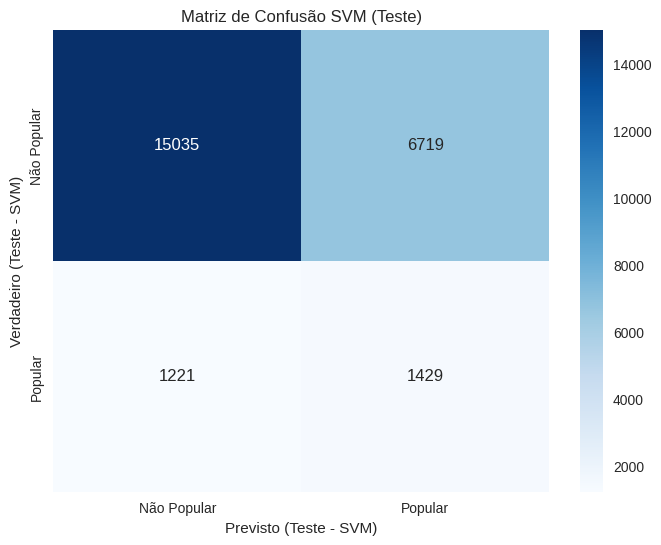


Métricas de Classificação (Teste - SVM):
              precision    recall  f1-score   support

 Não Popular       0.92      0.69      0.79     21754
     Popular       0.18      0.54      0.26      2650

    accuracy                           0.67     24404
   macro avg       0.55      0.62      0.53     24404
weighted avg       0.84      0.67      0.73     24404


Matriz de Confusão (Treino - SVM):
[[3698 1378]
 [ 363 4713]]


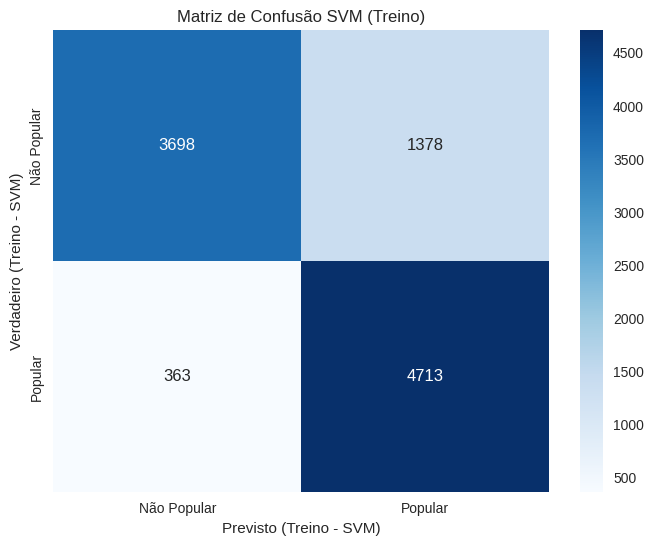


Métricas de Classificação (Treino - SVM):
              precision    recall  f1-score   support

 Não Popular       0.91      0.73      0.81      5076
     Popular       0.77      0.93      0.84      5076

    accuracy                           0.83     10152
   macro avg       0.84      0.83      0.83     10152
weighted avg       0.84      0.83      0.83     10152



In [ ]:
# 3. Avaliação do modelo

# Fazendo as previsões no conjunto de teste com SVM
y_pred_svm_test = svm_model.predict(X_test)

# Calculando e exibindo a matriz de confusão para o conjunto de teste com SVM
conf_matrix_svm_test = confusion_matrix(y_test, y_pred_svm_test)
print("Matriz de Confusão (Teste - SVM):")
print(conf_matrix_svm_test)

# Plotando a matriz de confusão para o conjunto de teste com SVM
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_svm_test, annot=True, fmt='d', cmap='Blues', xticklabels=['Não Popular', 'Popular'], yticklabels=['Não Popular', 'Popular'])
plt.xlabel('Previsto (Teste - SVM)')
plt.ylabel('Verdadeiro (Teste - SVM)')
plt.title('Matriz de Confusão SVM (Teste)')
plt.show()

# Exibindo as métricas de classificação para o conjunto de teste com SVM
print("\nMétricas de Classificação (Teste - SVM):")
print(classification_report(y_test, y_pred_svm_test, target_names=['Não Popular', 'Popular']))

# Fazendo as previsões no conjunto de treino com SVM
y_pred_svm_train = svm_model.predict(X_train_bal)

# Calculando e exibindo a matriz de confusão para o conjunto de treino com SVM
conf_matrix_svm_train = confusion_matrix(y_train_bal, y_pred_svm_train)
print("\nMatriz de Confusão (Treino - SVM):")
print(conf_matrix_svm_train)

# Plotando a matriz de confusão para o conjunto de treino com SVM
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_svm_train, annot=True, fmt='d', cmap='Blues', xticklabels=['Não Popular', 'Popular'], yticklabels=['Não Popular', 'Popular'])
plt.xlabel('Previsto (Treino - SVM)')
plt.ylabel('Verdadeiro (Treino - SVM)')
plt.title('Matriz de Confusão SVM (Treino)')
plt.show()

# Exibindo as métricas de classificação para o conjunto de treino com SVM
print("\nMétricas de Classificação (Treino - SVM):")
print(classification_report(y_train_bal, y_pred_svm_train, target_names=['Não Popular', 'Popular']))